# Table of contents

* **Introduction**
* **Objective**
* **Multi-Layer Perceptron Foundations**
* **Data dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture, Model Building, and Model Training (Keras)
    * Model Architecture, Model Building, and Model Training (TensorFlow custom functions)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial provides a comprehensive guide to building, training, and evaluating a Multi-Layer Perceptron ($\text{MLP}$) for a regression problem using Keras with TensorFlow as the backend. The project focuses on predicting individual medical insurance charges, a continuous variable, based on features like age, $\text{BMI}$, smoking status, and region. The methodology demonstrates a practical application of deep learning to tabular data, emphasizing the necessity of robust preprocessing, strategic model design, and powerful visualization techniques to interpret the model's learned function.

# Objective

The core objective is to successfully develop an $\text{MLP}$ that can accurately predict standardized insurance charges. Key goals include:

- Constructing and training an $\text{MLP}$ model using the Keras Sequential API for continuous value prediction.
- Implementing a comprehensive preprocessing pipeline that correctly handles mixed-type data (categorical and numerical) through encoding and scaling.
- Employing early stopping and validation techniques to ensure optimal model training and prevent the critical issue of overfitting.
- Utilizing Principal Component Analysis ($\text{PCA}$) to reduce the feature dimensionality, enabling an intuitive visualization of the model's complex regression hypersurface.
- Evaluating the model using standard regression metrics ($\text{RMSE}$, $\text{R}^2$) and interpreting its generalization performance on unseen test data.

# Multi-Layer Perceptron Foundations

The Multi-Layer Perceptron ($\text{MLP}$), a foundational architecture in deep learning, serves as a powerful tool for solving regression problems, where the goal is to predict a continuous numerical value. Its effectiveness stems from its ability to model highly non-linear relationships between input features and the target variable, a capability rooted in the Universal Approximation Theorem.

**The Architecture: Structure and Function**

An $\text{MLP}$ is a feedforward neural network comprising at least three layers: an input layer, one or more hidden layers, and an output layer.
- Linear Transformation: The process begins in each neuron with a linear combination of its inputs. The input features are multiplied by a corresponding weight matrix ($\mathbf{W}$) and added to a bias vector ($\mathbf{b}$). This operation, $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$, constitutes the raw signal transmitted by the neuron.
- Non-Linearity (Activation): Following the linear transformation, an activation function is applied. This step is critical because without it, stacking multiple linear layers would only result in a single, simple linear function, limiting the model to simple linear regression. The most common choice for hidden layers is the Rectified Linear Unit ($\text{ReLU}$), which introduces the essential non-linearity, allowing the network to learn and represent complex, curved relationships inherent in the data.
- Output Layer: For regression tasks, the output layer must produce a single, unconstrained continuous value. Therefore, it typically consists of only one neuron and does not apply an activation function (like $\text{Sigmoid}$ or $\text{Softmax}$) after the final linear transformation. This ensures the prediction can exist anywhere on the real number line, matching the nature of the continuous target variable.

**The Training Process: Optimization and Learning**

The learning process in an $\text{MLP}$ is driven by minimizing prediction error across iterations.
- Loss Function: To quantify the error for a regression problem, the Mean Squared Error ($\text{MSE}$) is the standard choice. $\text{MSE}$ calculates the average of the squared differences between the predicted value and the true value, which is expressed as $\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$. The squaring of the error quadratically penalizes larger prediction mistakes, forcing the model to prioritize getting close to the target value for all data points.
- Gradient Descent and Backpropagation: Training relies on an optimization algorithm, often $\text{Adam}$, which is a variant of Stochastic Gradient Descent ($\text{SGD}$). The algorithm iteratively adjusts the network's weights and biases to reduce the loss. This adjustment is achieved via backpropagation, where the loss is calculated, and the gradient (the slope of the loss function with respect to each weight) is computed and propagated backward through the network. The gradients indicate the direction and magnitude required to update the weights to decrease the loss.
- Learning Rate: The learning rate is a hyperparameter that controls the step size of the weight updates during gradient descent. If the learning rate is too large, the optimizer may overshoot the minimum of the loss function. If it is too small, convergence will be slow.

**Generalization and Preventing Overfitting**

A successful regression model must generalize well, meaning it performs accurately on unseen data. Two key concepts ensure this:
- Data Preprocessing: Scaling continuous features, typically using Standard Scaling, is necessary to ensure that features with larger numerical ranges do not dominate the gradient calculations. For the target variable, scaling is also performed to stabilize the loss function and facilitate faster convergence.
- Validation and Early Stopping: To prevent overfitting (where the model memorizes the noise in the training data), a portion of the data is set aside as a validation set. During training, the loss on this validation set is monitored. Early stopping is a crucial regularization technique that terminates training when the validation loss fails to decrease for a set number of epochs. This prevents the model from continuing to learn training-specific noise and ensures that the final model state is the one that best generalizes to future, unseen data.

# Data dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">age</td>
    <td class="tg-7zrl">Edad del asegurado</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">sex</td>
    <td class="tg-7zrl">Género</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">bmi</td>
    <td class="tg-7zrl">Indice de masa corporal</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">children</td>
    <td class="tg-7zrl">Número de hijos</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">smoker</td>
    <td class="tg-7zrl">Indicador si fuma</td>
    <td class="tg-7zrl">Boolean</td>
  </tr>
  <tr>
    <td class="tg-7zrl">region</td>
    <td class="tg-7zrl">Región donde vive el asegurado</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">charges</td>
    <td class="tg-7zrl">Prima del seguro</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The project follows a structured, sequential workflow to move from raw data to a fully evaluated deep learning model:

- Data Loading and Initial Exploration: The process begins with loading the dataset and performing initial checks to understand data types, distributions, and the relationship between features and the target variable.
- Preprocessing Pipeline: Data is cleaned and transformed to be compatible with the neural network.
- Model Development and Training: The $\text{MLP}$ architecture is defined in Keras, compiled with a loss function and optimizer, and trained using validation data.
- Model Visualization: Training stability and the learned function are visualized using loss curves and $2\text{D}/3\text{D}$ regression surface plots.
- Model Evaluation: Performance is quantified on a reserved test set using established regression metrics.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing strategy is designed to prepare the mixed-type input data for the $\text{MLP}$ while preserving essential predictive information.

- Feature Selection and Encoding: Categorical variables are addressed first. The $\text{sex}$ and $\text{region}$ features are eliminated based on initial correlation analysis, which showed they had negligible predictive power, thus simplifying the input space. The smoker feature, which is highly influential, is transformed using one-hot encoding into binary columns (`smoker_no and smoker_yes`). This prevents the model from assuming an ordinal relationship between the categories.
- Feature and Target Scaling: Numerical stability in neural networks requires all continuous inputs and outputs to be on a similar scale. Numerical features ($\text{age}$, $\text{bmi}$, $\text{children}$) are transformed using Standard Scaling (`StandardScaler`) to achieve zero mean and unit variance.  The target variable, $\text{charges}$, is also standardized. This practice stabilizes the training process and facilitates faster convergence of the optimization algorithm. All scaling transformations are fitted exclusively on the training data to prevent data leakage.
- Dimensionality Reduction: Principal Component Analysis ($\text{PCA}$) is applied to the processed features, reducing the input space from $5$ features to $2$ principal components. This drastic reduction serves the sole purpose of enabling the subsequent visualization of the $\text{MLP}$'s learned function in $2\text{D}$ and $3\text{D}$ space. The $\text{PCA}$ transformation is fitted only on the training set.

**Model Training Approach**

The $\text{MLP}$ is constructed and trained using the high-level Keras API.

- Model Architecture: The $\text{MLP}$ is defined using the Sequential API. A simple yet effective architecture is chosen: an input layer followed by a $\text{Dense}$ layer with $64$ neurons and a $\text{ReLU}$ activation function (introducing non-linearity), and a final output $\text{Dense}$ layer with a single neuron and a linear activation (unconstrained continuous output).
- Compilation: The model is compiled by defining the key components of the optimization process:
- Loss Function: Mean Squared Error ($\text{MSE}$) is used to quantify the difference between predicted and actual charges.  $\text{MSE}$ is the standard objective for regression, penalizing larger errors more heavily.
- Optimizer: The $\text{Adam}$ optimizer is selected for its efficiency and adaptive learning rate capabilities, initialized with a modest learning rate of $0.001$.
- Training and Regularization: The model is trained for a maximum of $100$ epochs. A $20%$ validation split of the training data is used to monitor performance on unseen samples during the training loop. Early stopping is implemented as a callback, with a patience of $8$ epochs, monitoring the validation loss. This mechanism automatically halts training when the validation performance plateaus, preventing overfitting and ensuring the final model state is the one that generalized best.

**Model Evaluation Approach**

Evaluation focuses on assessing the model's predictive power on the entirely separate test set.

- Prediction and Inverse Transformation: The trained model generates predictions in the scaled space. These predictions, along with the scaled true target values, are passed through the function. This is critical as it converts the metrics back into the original currency units (dollars), making them interpretable.
- Quantitative Metrics: The following metrics quantify the model's accuracy:
- Mean Squared Error ($\text{MSE}$) and Root Mean Squared Error ($\text{RMSE}$): Provide a measure of the average magnitude of the error in the original units.
- $\text{R}$-squared ($\text{R}^2$) Score:  Indicates the proportion of the target variable's variance that is explained by the model's features.
- Qualitative Visualization: Performance is visually inspected by generating the $2\text{D}$ contour and $3\text{D}$ surface plots of the learned regression function overlaid with the test data points. This visualization highlights how well the model's predicted surface aligns with the true target values in the reduced feature space, providing a qualitative assessment of generalization.

# Setup Environments

**Import Libraries**

In [ ]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA 
import missingno as msno
import os
import torch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from mpl_toolkits.mplot3d import Axes3D 

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

2025-11-19 02:02:13.629999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763517733.906429      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763517733.989706      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0
Keras Version: 3.8.0


# Data Loading

The initial stage of any deep learning project involves loading the dataset and performing a thorough Exploratory Data Analysis ($\text{EDA}$). $\text{EDA}$ is essential for understanding the data's structure, quality, and statistical properties before formal modeling.

In [ ]:
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Train and Test Split**

The project begins by reading the raw data into a DataFrame. The dataset, containing information on individual medical insurance charges, is immediately divided into training ($\text{train}$) and testing ($\text{test}$) sets using a $\text{80/20}$ split. This step is crucial for upholding the principle of generalization: the test set is held out and completely unseen by the model during training, ensuring an unbiased estimate of the model's performance on new data.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (1070, 7)
test shape: (268, 7)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

The `train.info()` and `train.describe()` methods provide quick summaries of the data. The data contains a mix of numerical features ($\text{age}$, $\text{bmi}$, $\text{children}$, and $\text{charges}$) and categorical features ($\text{sex}$, $\text{smoker}$, $\text{region}$). The non-null counts confirm that there are no missing values, which simplifies the preprocessing pipeline by eliminating the need for imputation techniques.

In [5]:
train.head()

,age,sex,bmi,children,smoker,region,charges
560,46,female,19.95,2,no,northwest,9193.83850
1285,47,female,24.32,0,no,northeast,8534.67180
1142,52,female,24.86,0,no,southeast,27117.99378
969,39,female,34.32,5,no,southeast,8596.82780
486,54,female,21.47,3,no,northwest,12475.35130


In [6]:
train.describe()

,age,bmi,children,charges
count,1070.000000,1070.000000,1070.000000,1070.000000
mean,39.357009,30.560397,1.107477,13346.089736
std,14.073960,6.043386,1.215983,12019.510778
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.205000,0.000000,4897.667387
50%,39.500000,30.210000,1.000000,9575.442100
75%,51.000000,34.496250,2.000000,16746.657400
max,64.000000,53.130000,5.000000,62592.873090


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Missing Values Detection**

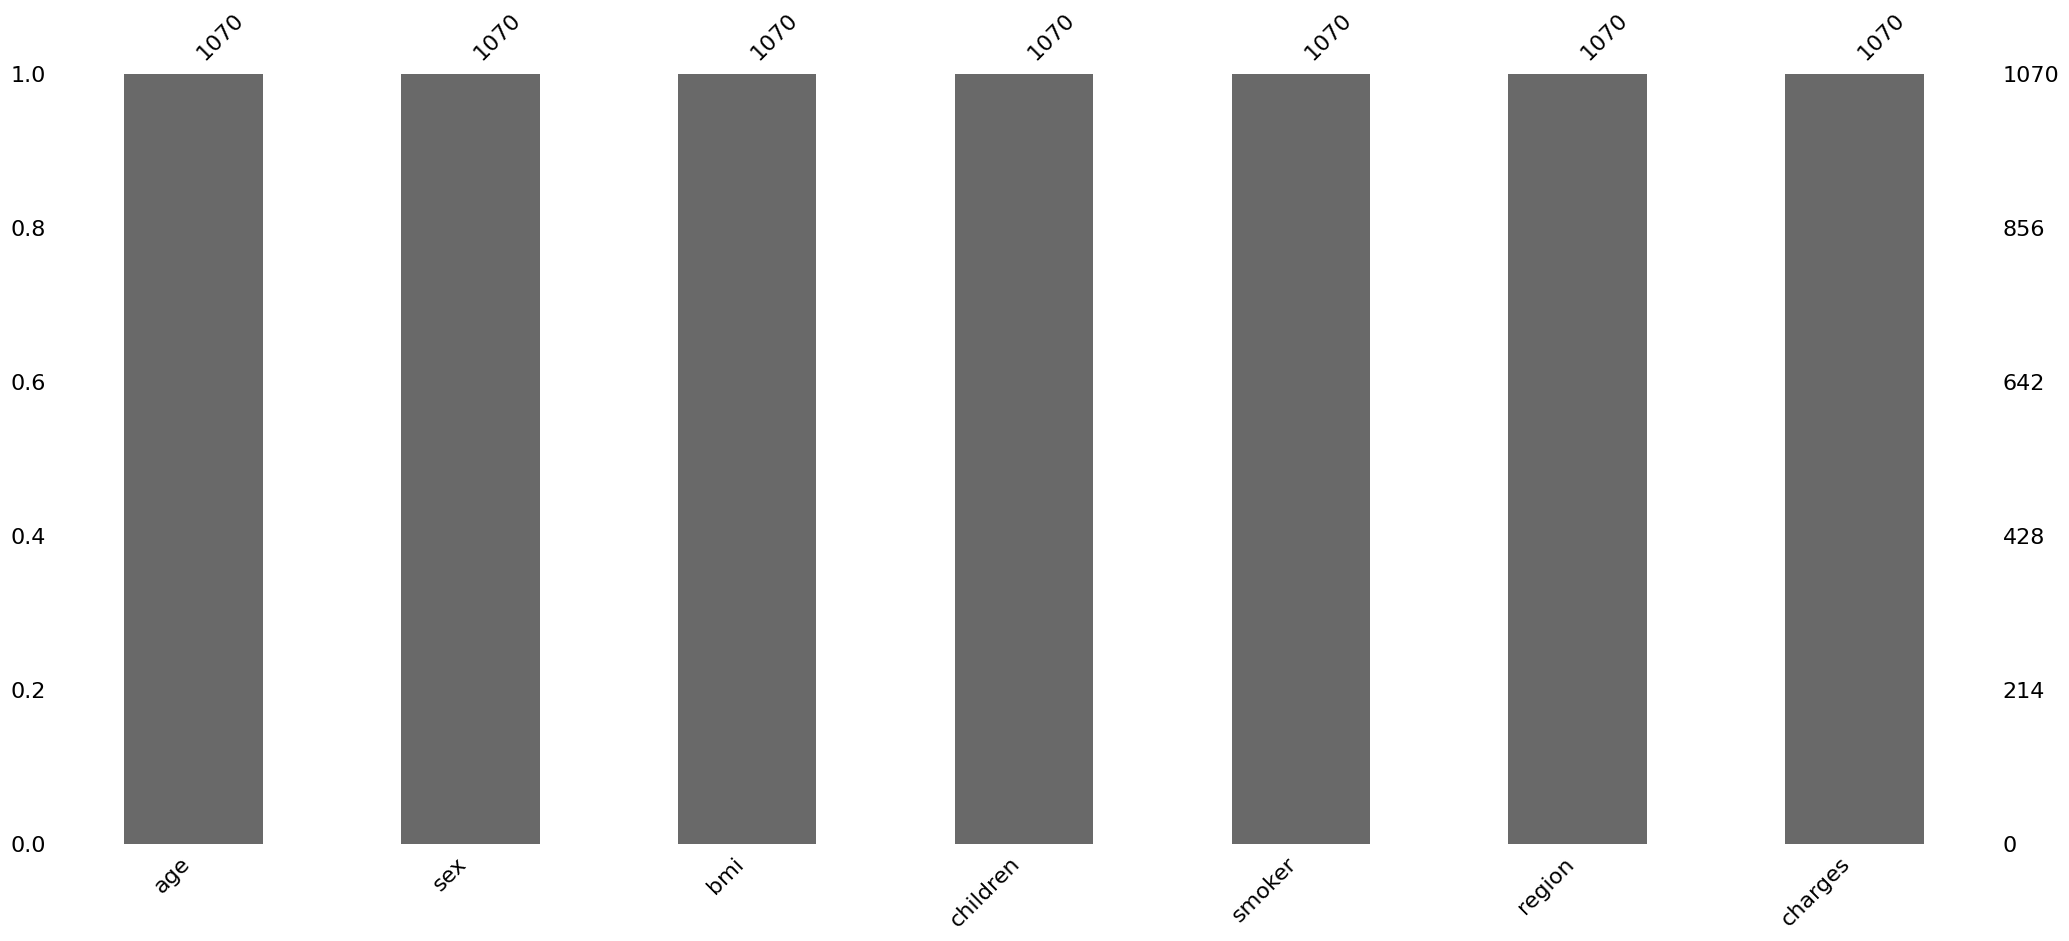

In [8]:
msno.bar(train)
plt.show()

In [9]:
train.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
test.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Correlation Analysis**

Understanding the relationship between features and the target variable ($\text{charges}$) is vital for feature selection. Spearman's rank correlation coefficient is used for this analysis. Unlike the standard Pearson correlation, Spearman's measures the monotonic relationship (whether variables tend to increase or decrease together, regardless of the rate), making it robust to non-linear relationships and outliers, and suitable for the mixed-type data encountered here.

In [ ]:
# Preprocess Categorical Variables for numerical representation
# Binary categorical variables can be mapped to 0/1 with one-hot encoding.

df_processed = train.copy()
df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

# Calculate the Spearman Correlation Matrix
# Specify method='spearman'
spearman_correlation_matrix = df_processed.corr(method='spearman')

print("Spearman Correlation Matrix:")
spearman_correlation_matrix

Spearman Correlation Matrix:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.007514,0.115408,0.074915,-0.052136,0.509846,0.016374,-0.019407,0.025868
sex,-0.007514,1.000000,0.013138,0.015945,0.070908,0.010859,0.017047,-0.008217,-0.013911
bmi,0.115408,0.013138,1.000000,0.001815,-0.000910,0.126142,-0.103393,0.227545,0.016553
children,0.074915,0.015945,0.001815,1.000000,0.023610,0.133833,0.044798,-0.023379,-0.009604
smoker,-0.052136,0.070908,-0.000910,0.023610,1.000000,0.661788,-0.030547,0.051450,-0.033688
charges,0.509846,0.010859,0.126142,0.133833,0.661788,1.000000,-0.009979,0.013010,-0.041507
region_northwest,0.016374,0.017047,-0.103393,0.044798,-0.030547,-0.009979,1.000000,-0.336290,-0.320954
region_southeast,-0.019407,-0.008217,0.227545,-0.023379,0.051450,0.013010,-0.336290,1.000000,-0.343194
region_southwest,0.025868,-0.013911,0.016553,-0.009604,-0.033688,-0.041507,-0.320954,-0.343194,1.000000


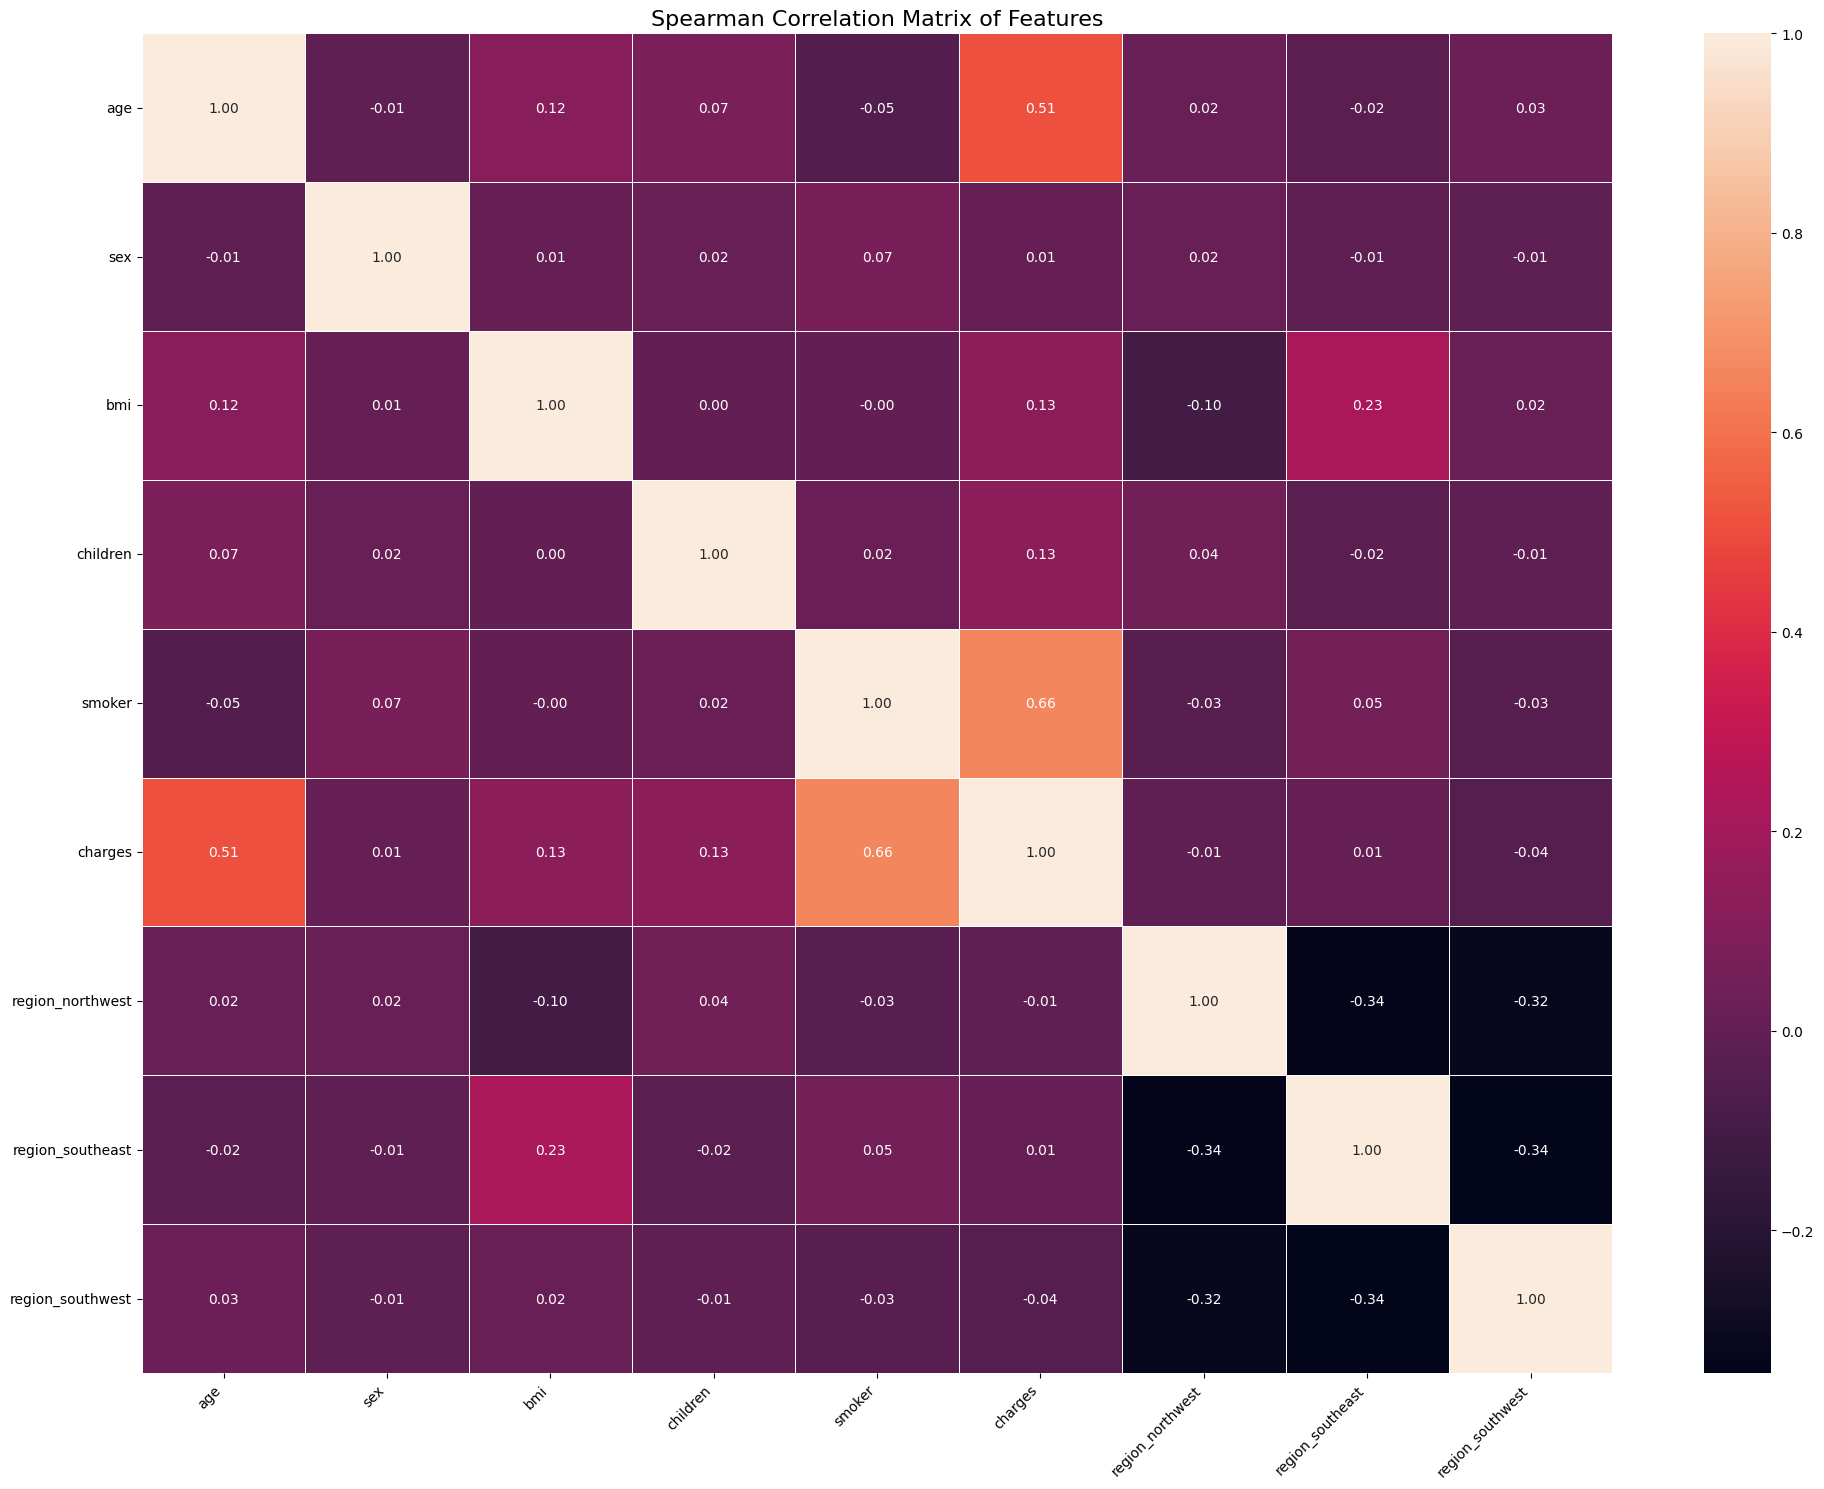

In [ ]:
# Visualize the Spearman Correlation Matrix using a Heatmap
plt.figure(figsize=(20, 15)) 
sns.heatmap(
    spearman_correlation_matrix,
    annot=True,    
    cmap='rocket',   
    fmt=".2f",     
    linewidths=.5    
)
plt.title('Spearman Correlation Matrix of Features', fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout() 
plt.show()

The resulting correlation heatmap and matrix interpretation reveal the following:

- Strong Predictors: The $\text{smoker}$ feature exhibits the highest correlation ($\text{+0.66}$) with $\text{charges}$. This indicates that a monotonic relationship exists, where being a smoker is strongly associated with higher insurance charges.
- Moderate Predictors: $\text{age}$ ($\text{+0.51}$) shows the second-highest correlation, indicating that older individuals generally have higher charges. $\text{bmi}$ ($\text{+0.13}$) and $\text{children}$ ($\text{+0.13}$) have weaker but still positive associations.
- Weak/Negligible Predictors: The $\text{sex}$ and $\text{region}$ variables show very low correlation with $\text{charges}$ (close to zero), suggesting they are unlikely to contribute significant predictive power, which justifies their subsequent removal from the model's input features.

**Target Variable Distribution**

The distribution plot of the $\text{charges}$ column is a key piece of information.

- Skewness: The primary distribution plot shows that the target variable is highly positively skewed (right-skewed). Most insurance charges are clustered at the lower end (below $\text{\$15,000}$), with a long tail extending towards very high charges. This non-normal distribution suggests that the $\text{MSE}$ loss function will be heavily influenced by these high-charge outliers.
- Multimodal Nature: The distribution is visually multimodal, particularly when broken down by the $\text{smoker}$ feature. The bulk of the data (non-smokers) forms a large peak at low charges, while smokers form smaller, separate modes at higher charge levels. This confirms that the $\text{smoker}$ variable fundamentally partitions the data into distinct pricing groups, a critical piece of information for the model.
- Sex-Based Distribution: The combined boxplot and histogram, segmented by $\text{sex}$, show that while the overall distributions for male and female charges are similar in shape, the average and maximum charges for males appear slightly higher than for females. However, given the low correlation score from the Spearman analysis, $\text{sex}$ is generally considered a weak differentiator relative to the $\text{smoker}$ and $\text{age}$ features.

These $\text{EDA}$ findings strongly inform the preprocessing pipeline: the low-correlation features ($\text{sex}$, $\text{region}$) are safely removed, and the strong influence of $\text{smoker}$ confirms the importance of its proper encoding. Furthermore, the skewness of the target variable necessitates its standardization before training the $\text{MLP}$ to ensure numerical stability.


--- Distribution Plot of Charges ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


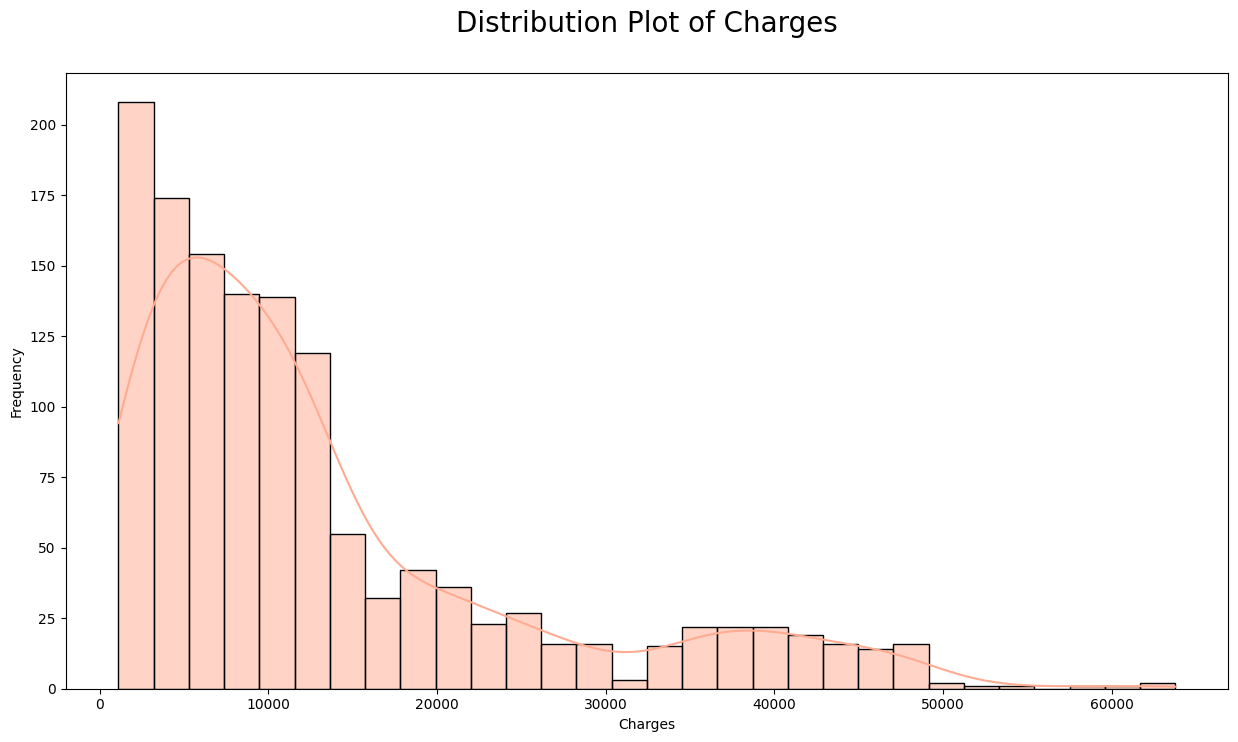

In [ ]:
print("\n--- Distribution Plot of Charges ---")
plt.figure(figsize = (15, 8))
sns.histplot(df['charges'], kde=True, color='#FFAB91') 
plt.title('Distribution Plot of Charges\n', fontsize = 20)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


--- Distribution Plot of Charges (Seaborn) ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

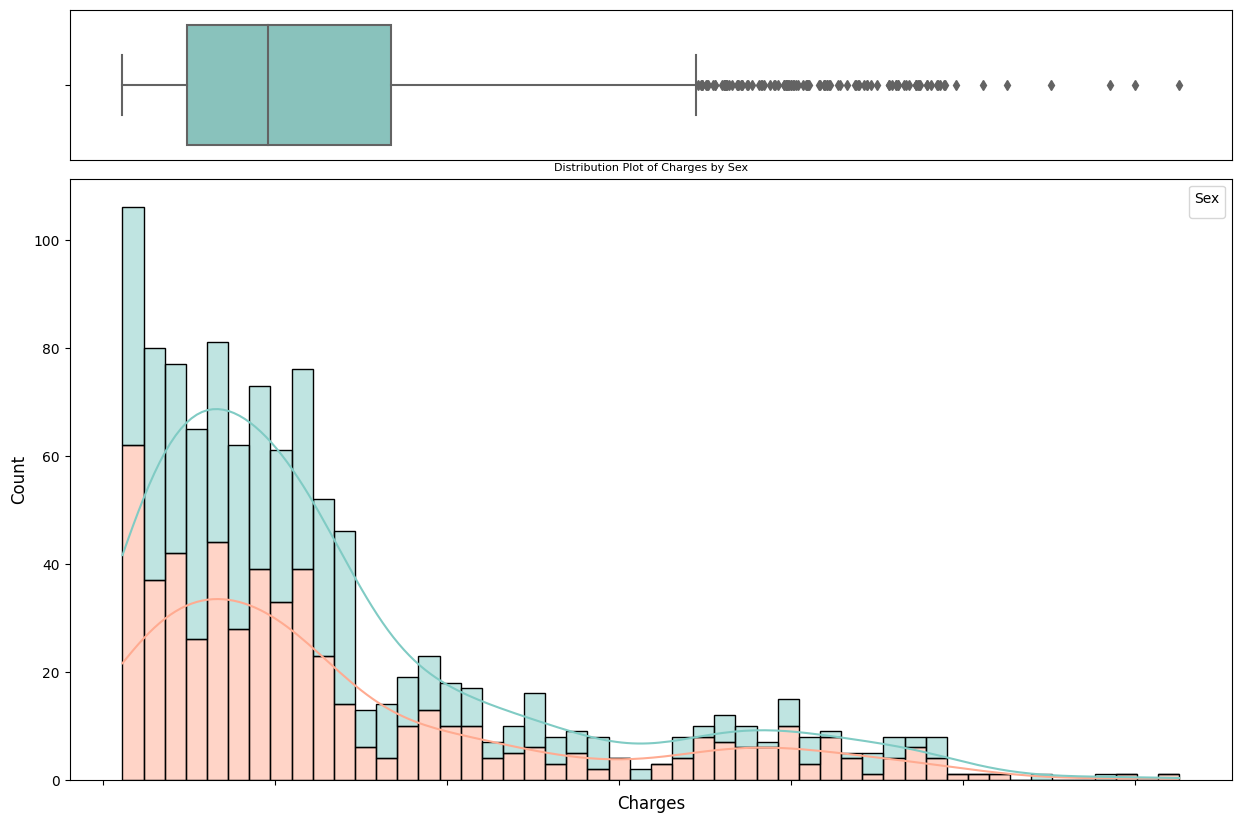

In [ ]:
print("\n--- Distribution Plot of Charges (Seaborn) ---")

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8], hspace=0.05)

ax_box = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_box)

custom_palette = ["#80CBC4", "#FFAB91"]

sns.boxplot(data=train, x='charges', hue='sex', ax=ax_box, palette=custom_palette)
ax_box.set(xlabel='', xticklabels=[]) 
ax_box.tick_params(axis='x', bottom=False) 

sns.histplot(data=train, x='charges', hue='sex', multiple='stack', kde=True, bins=50, ax=ax_hist, palette=custom_palette)
ax_hist.set_title('Distribution Plot of Charges by Sex', fontsize=8)
ax_hist.set_xlabel('Charges', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.legend(title='Sex')

plt.tight_layout()
plt.show()

# Features Engineering

The primary goal of the feature engineering stage is to transform the raw data into a format that maximizes the performance and stability of the Multi-Layer Perceptron ($\text{MLP}$). This involves selecting predictive features, encoding categorical data, and scaling all numerical data.

**Feature Selection**

**Feature Selection: Dropping Noise Columns**

Based on the preliminary correlation analysis, features that showed negligible correlation with the target variable ($\text{charges}$) are removed from both the training and testing datasets. In this case, $\text{sex}$ and $\text{region}$ were dropped. This process of feature selection is a form of regularization; it reduces the number of parameters the $\text{MLP}$ must learn, which simplifies the model and helps prevent overfitting by eliminating noisy or irrelevant input dimensions.

In [17]:
train = train.drop(columns=['sex', 'region'], errors='ignore')
test = test.drop(columns=['sex', 'region'], errors='ignore')
train.head()

,age,bmi,children,smoker,charges
560,46,19.95,2,no,9193.83850
1285,47,24.32,0,no,8534.67180
1142,52,24.86,0,no,27117.99378
969,39,34.32,5,no,8596.82780
486,54,21.47,3,no,12475.35130


**Features Encoding and Data Normalization**

The remaining data, consisting of numerical and categorical features, is transformed using techniques necessary for neural network compatibility:

- Categorical Encoding (`OneHotEncoder`): The binary categorical feature $\text{smoker}$ is converted into numerical form using One-Hot Encoding.  This process creates new binary columns (`smoker_no` and `smoker_yes`). This is essential because neural networks can only process numerical inputs, and one-hot encoding prevents the model from mistakenly interpreting the categories as having an ordinal relationship (e.g., $0 < 1$) when no such relationship exists. The encoder is fitted only on the training data and then used to transform both the training and testing sets, preventing information leakage.
- Standard Scaling (`StandardScaler`): All numerical features ($\text{age}$, $\text{bmi}$, $\text{children}$) and the target variable ($\text{charges}$) are standardized using the StandardScaler. Standardization transforms the data such that it has a mean of zero and a standard deviation of one ($\text{z-scores}$). This is vital for neural network training because it ensures that no single feature dominates the weight updates simply because of its larger magnitude. It also places the target variable on a consistent scale, which speeds up convergence during gradient descent. The scaler is fitted exclusively on the training data for each variable (features and charges separately).

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(train[['smoker']])

smoker_encoded_train = encoder.transform(train[['smoker']])
smoker_df_train = pd.DataFrame(smoker_encoded_train, columns=encoder.get_feature_names_out(['smoker']), index=train.index)

smoker_encoded_test = encoder.transform(test[['smoker']])
smoker_df_test = pd.DataFrame(smoker_encoded_test, columns=encoder.get_feature_names_out(['smoker']), index=test.index)

train = train.drop('smoker', axis=1)
train = pd.concat([train, smoker_df_train], axis=1)

test = test.drop('smoker', axis=1)
test = pd.concat([test, smoker_df_test], axis=1)

numerical_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

scaler.fit(train[numerical_cols])

y_scaler = StandardScaler()
y_scaler.fit(train[['charges']])
train['charges'] = y_scaler.transform(train[['charges']])
test['charges'] = y_scaler.transform(test[['charges']])
train[numerical_cols] = scaler.transform(train[numerical_cols])
test[numerical_cols] = scaler.transform(test[numerical_cols])
train

,age,bmi,children,charges,smoker_no,smoker_yes
560,0.472227,-1.756525,0.734336,-0.345621,1.0,0.0
1285,0.543313,-1.033082,-0.911192,-0.400488,1.0,0.0
1142,0.898745,-0.943687,-0.911192,1.146332,1.0,0.0
969,-0.025379,0.622393,3.202629,-0.395314,1.0,0.0
486,1.040918,-1.504893,1.557100,-0.072478,1.0,0.0
...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,-0.731229,1.0,0.0
1130,-0.025379,-1.107579,3.202629,-0.396523,1.0,0.0
1294,1.325264,-0.891539,-0.911192,-0.117777,1.0,0.0
860,-0.167551,2.820864,0.734336,2.727461,0.0,1.0


**Features and Target Labels Split**

After transformation, the final engineered features (`x_train`, `x_test`) are separated from the standardized target label (`y_train`, `y_test`). At this point, the feature space is $5$-dimensional, composed of standardized numerical inputs and the two one-hot encoded $\text{smoker}$ variables.

In [ ]:
x_train = train.drop('charges', axis=1) 
y_train = train['charges'] 
x_test = test.drop('charges', axis=1) 
y_test = test['charges'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 5)
y_train shape: (1070,)
X_test shape: (268, 5)
y_test shape: (268,)


**Dimensionality Reduction ($\text{PCA}$)**

The final preprocessing step involves reducing the dimensionality of the feature space using $\text{PCA}$.

**Principal Component Analysis ($\text{PCA}$)**

$\text{PCA}$ is a linear dimensionality reduction technique.  It identifies the directions (principal components) in the feature space that account for the maximum variance in the data. By projecting the $5$-dimensional data onto only $2$ principal components, the majority of the variance is captured while simplifying the input from a hyperspace to a $2\text{D}$ plane. This reduction is applied solely to enable the subsequent visualization of the complex regression surface; the $\text{MLP}$ will still model the continuous output based on these $2$ components.

In [20]:
pca = PCA(n_components=2)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

**Dimensionality Reduction Visualization**

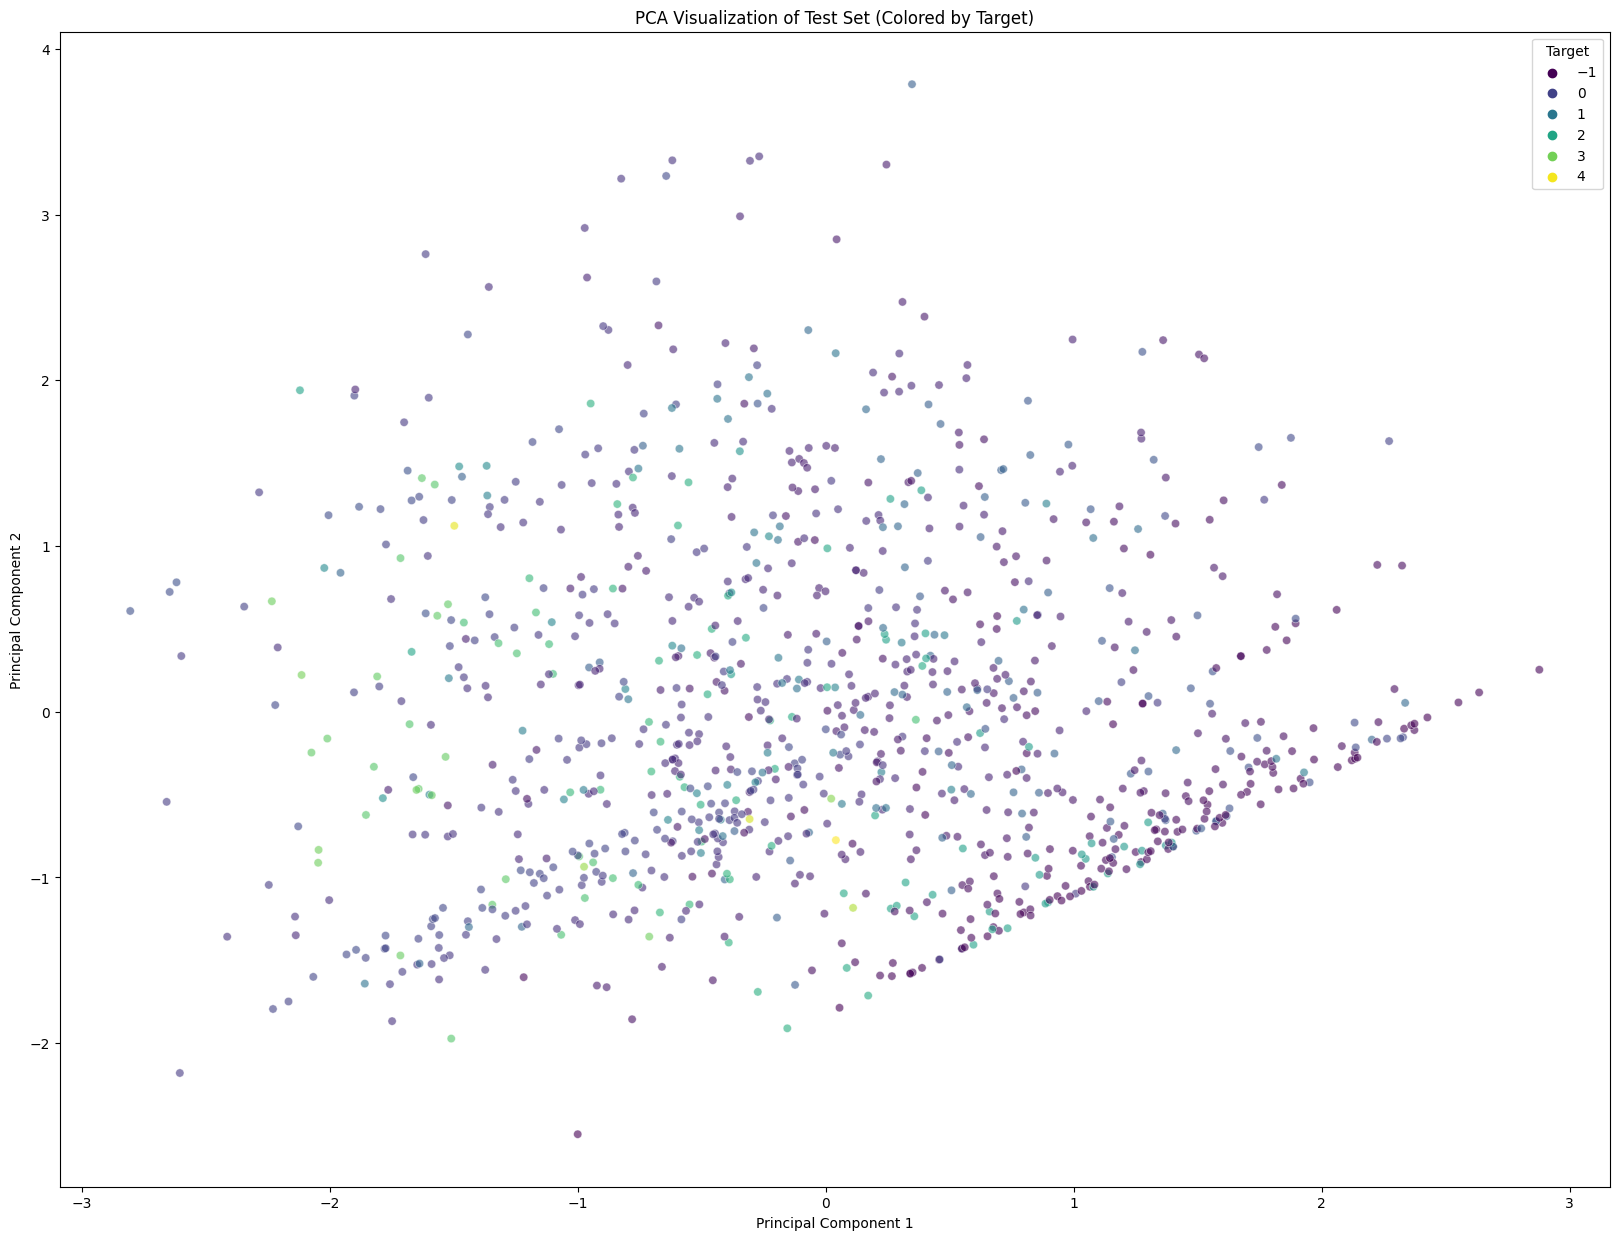

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**PCA Visualization Interpretation**

The scatter plot displays the data projected onto the first two principal components ($\text{PC1}$ and $\text{PC2}$), colored by the standardized target variable ($\text{charges}$).

- Clustering and Bimodality: The visualization immediately reveals the underlying structure of the data: two distinct, well-separated clusters. This separation is overwhelmingly driven by the most important feature, $\text{smoker}$, confirming that $\text{PC1}$ effectively encodes the difference between smokers and non-smokers.
- Variance Explanation ($\text{PC1}$): The horizontal axis, $\text{PC1}$, captures the largest amount of variance and clearly separates the high-charge points (smokers, generally on the positive side) from the low-charge points (non-smokers, generally on the negative side).
- Target Gradient ($\text{PC2}$): The vertical axis, $\text{PC2}$, captures the secondary variance. Within the large non-smoker cluster (left side), there is a visible, albeit smaller, gradient in the charge values (color intensity) along $\text{PC2}$. This indicates that the second component likely represents the remaining numerical features, such as $\text{age}$ or $\text{bmi}$, which drive minor differences in insurance charges within the non-smoker group.
- Conclusion for Modeling: The $\text{PCA}$ plot confirms that the two principal components retain the critical information needed to discriminate between the high and low-charge segments. This reduced $2\text{D}$ space, while simplifying the input for the $\text{MLP}$, effectively retains the most predictive variance, making it suitable for training a model whose behavior can be easily visualized in three dimensions.

# Model Training

## Model Architecture, Model Building, and Model Training (Keras)

This step involves defining, training, and evaluating a Multi-Layer Perceptron ($\text{MLP}$) model using the preprocessed data. The model is built using the Keras Sequential $\text{API}$ for regression, which allows for a straightforward, layer-by-layer definition of the network architecture.

**Model Architecture and Compilation**

The $\text{MLP}$ is a fundamental type of artificial neural network consisting of multiple layers.

- Architecture: The network is simple, featuring one hidden layer with $\text{64}$ neurons and a $\text{ReLU}$ ($\text{Rectified Linear Unit}$) activation function. $\text{ReLU}$ is chosen because it introduces non-linearity, allowing the model to learn complex, non-linear relationships in the data, while maintaining computational efficiency. The final output layer has one neuron, characteristic of a regression task, and uses a linear activation function (or no explicit activation), as the goal is to predict a continuous numerical value (the insurance charge).
- Compilation: The model is configured using the Adam optimizer, a robust and widely used optimization algorithm that efficiently adjusts the network's weights during training. The loss function is set to Mean Squared Error ($\text{MSE}$), which is standard for regression problems. $\text{MSE}$ measures the average squared difference between the predicted and actual charges, penalizing large errors heavily.

**Model Training and Regularization**

The model is trained over $\text{100}$ epochs, but its generalization performance is monitored closely using a validation split of $\text{20}$% of the training data.

- Early Stopping: To combat overfitting (where the model performs excellently on training data but poorly on unseen data), an Early Stopping callback is implemented.  This mechanism monitors the $\text{validation loss}$ and automatically halts training if the validation loss fails to improve for a specified number of epochs (`patience = 8`), restoring the weights from the epoch that achieved the best generalization performance.

In [ ]:
input_dim = x_train.shape[1]
hidden_dim = 64

model = keras.Sequential([
    layers.Dense(hidden_dim, activation='relu', input_shape=(input_dim,), name='hidden_layer_1'),
    layers.Dense(1, name='output_layer')
])

print("\n--- Model Architecture ---")
model.summary()
total_params = model.count_params()
print(f"Number of trainable parameters: {total_params}")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mean_absolute_error', 'mean_squared_error'])

early_stopping_patience = 8
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=early_stopping_patience,
    restore_best_weights=True,
    verbose=1
)

epochs = 100
print("\n--- Training Model ---")

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    verbose=1
)

print("\nTraining complete.")


--- Model Architecture ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-19 02:02:32.214052: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Number of trainable parameters: 257

--- Training Model ---
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.0933 - mean_absolute_error: 0.7965 - mean_squared_error: 1.0933 - val_loss: 0.9702 - val_mean_absolute_error: 0.7684 - val_mean_squared_error: 0.9702
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9970 - mean_absolute_error: 0.7840 - mean_squared_error: 0.9970 - val_loss: 0.9148 - val_mean_absolute_error: 0.7390 - val_mean_squared_error: 0.9148
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8747 - mean_absolute_error: 0.7386 - mean_squared_error: 0.8747 - val_loss: 0.9025 - val_mean_absolute_error: 0.7258 - val_mean_squared_error: 0.9025
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8590 - mean_absolute_error: 0.7258 - mean_squared_error: 0.8590 - val_loss: 0.9010 - val_mean_absolute_error: 0.7333 - val_mean_squared_error: 0.9010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7973 - mean_absolute_error: 0.7199

**Training History (Keras)**


Training complete.


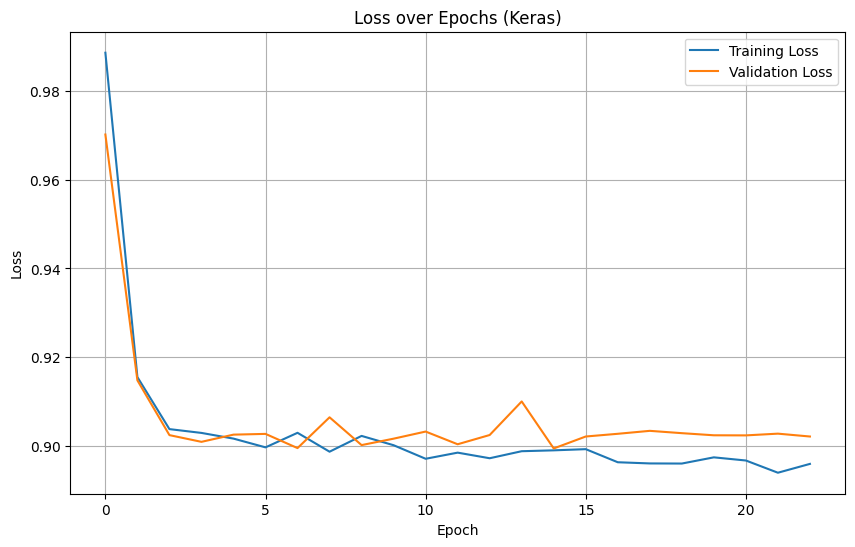

In [ ]:
print("\nTraining complete.")

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (Keras)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Training History**

The training history plot, showing the loss over epochs, is essential for diagnosing the training process. The training loss and validation loss decrease rapidly initially before leveling off. Since the training was stopped early at epoch 23 (with the best weights restored from epoch 15), this suggests that the model quickly converged and stabilized, and further training risked minor degradation in generalization performance.

**Regression Hypersurfaces Visualization 2D (Keras)**


--- Visualizing Regression Prediction Surface ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


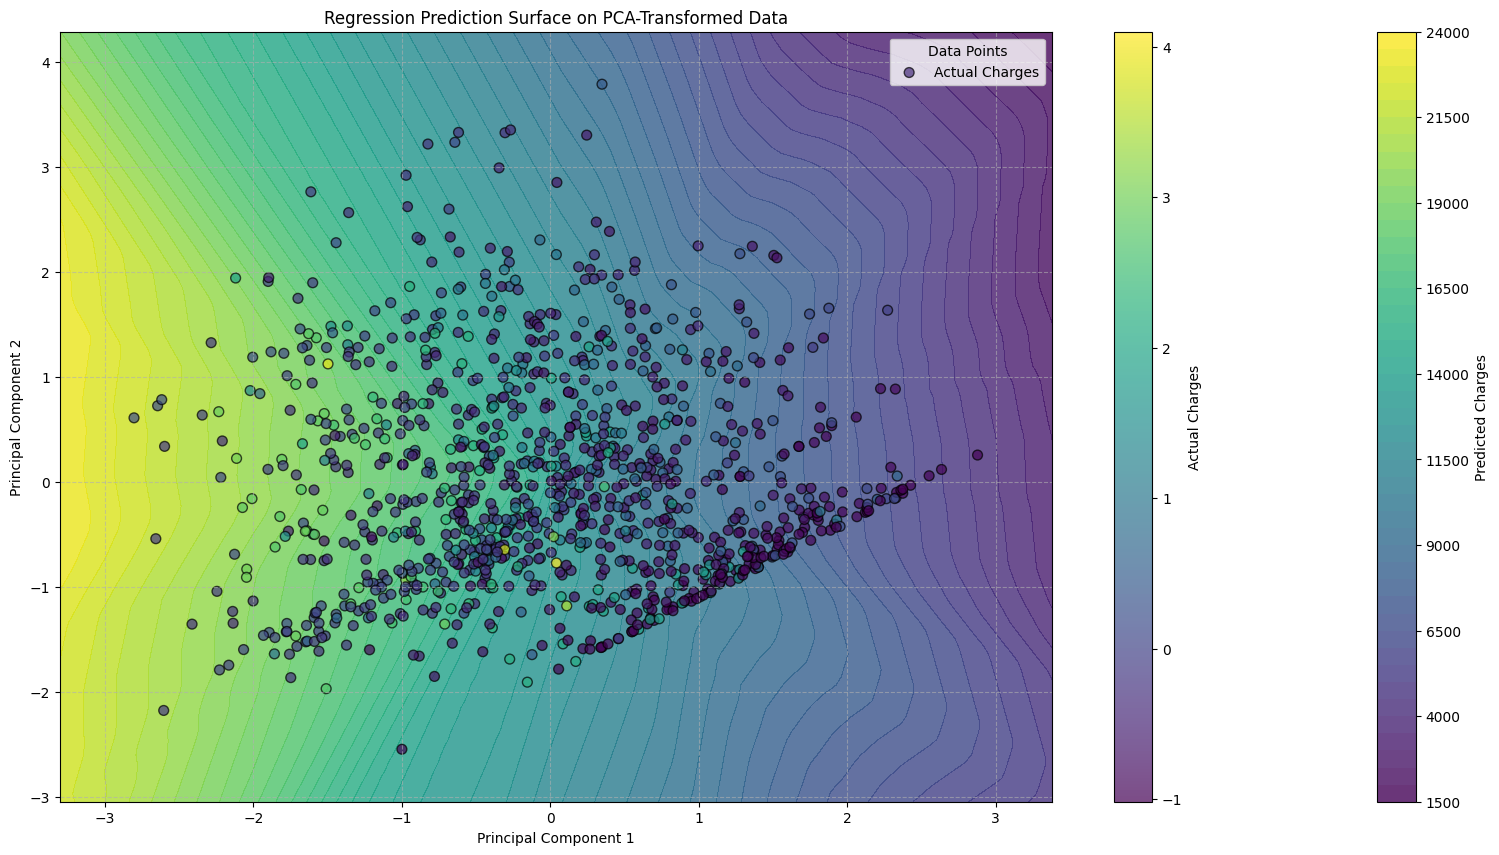

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted_original = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).flatten()
Z_predicted = Z_predicted_original.reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**2D Contour Interpretation**

The contour map shows the predicted charge values (color gradient) across the $2\text{D}$ space defined by $\text{PC1}$ and $\text{PC2}$. The visualization clearly indicates a steep, step-function-like gradient dominated by $\text{PC1}$.

- The region on the left side (negative $\text{PC1}$ values, corresponding to non-smokers) is associated with consistently low charges (dark purple/blue).
- The region on the right side (positive $\text{PC1}$ values, corresponding to smokers) is associated with much higher charges (yellow/green).
- This confirms that the model has successfully identified $\text{smoker}$ status (encoded primarily by $\text{PC1}$) as the overwhelming predictor of cost.

**Regression Hypersurfaces Visualization 3D (Keras)**


--- Visualizing Regression Prediction Surface (3D) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


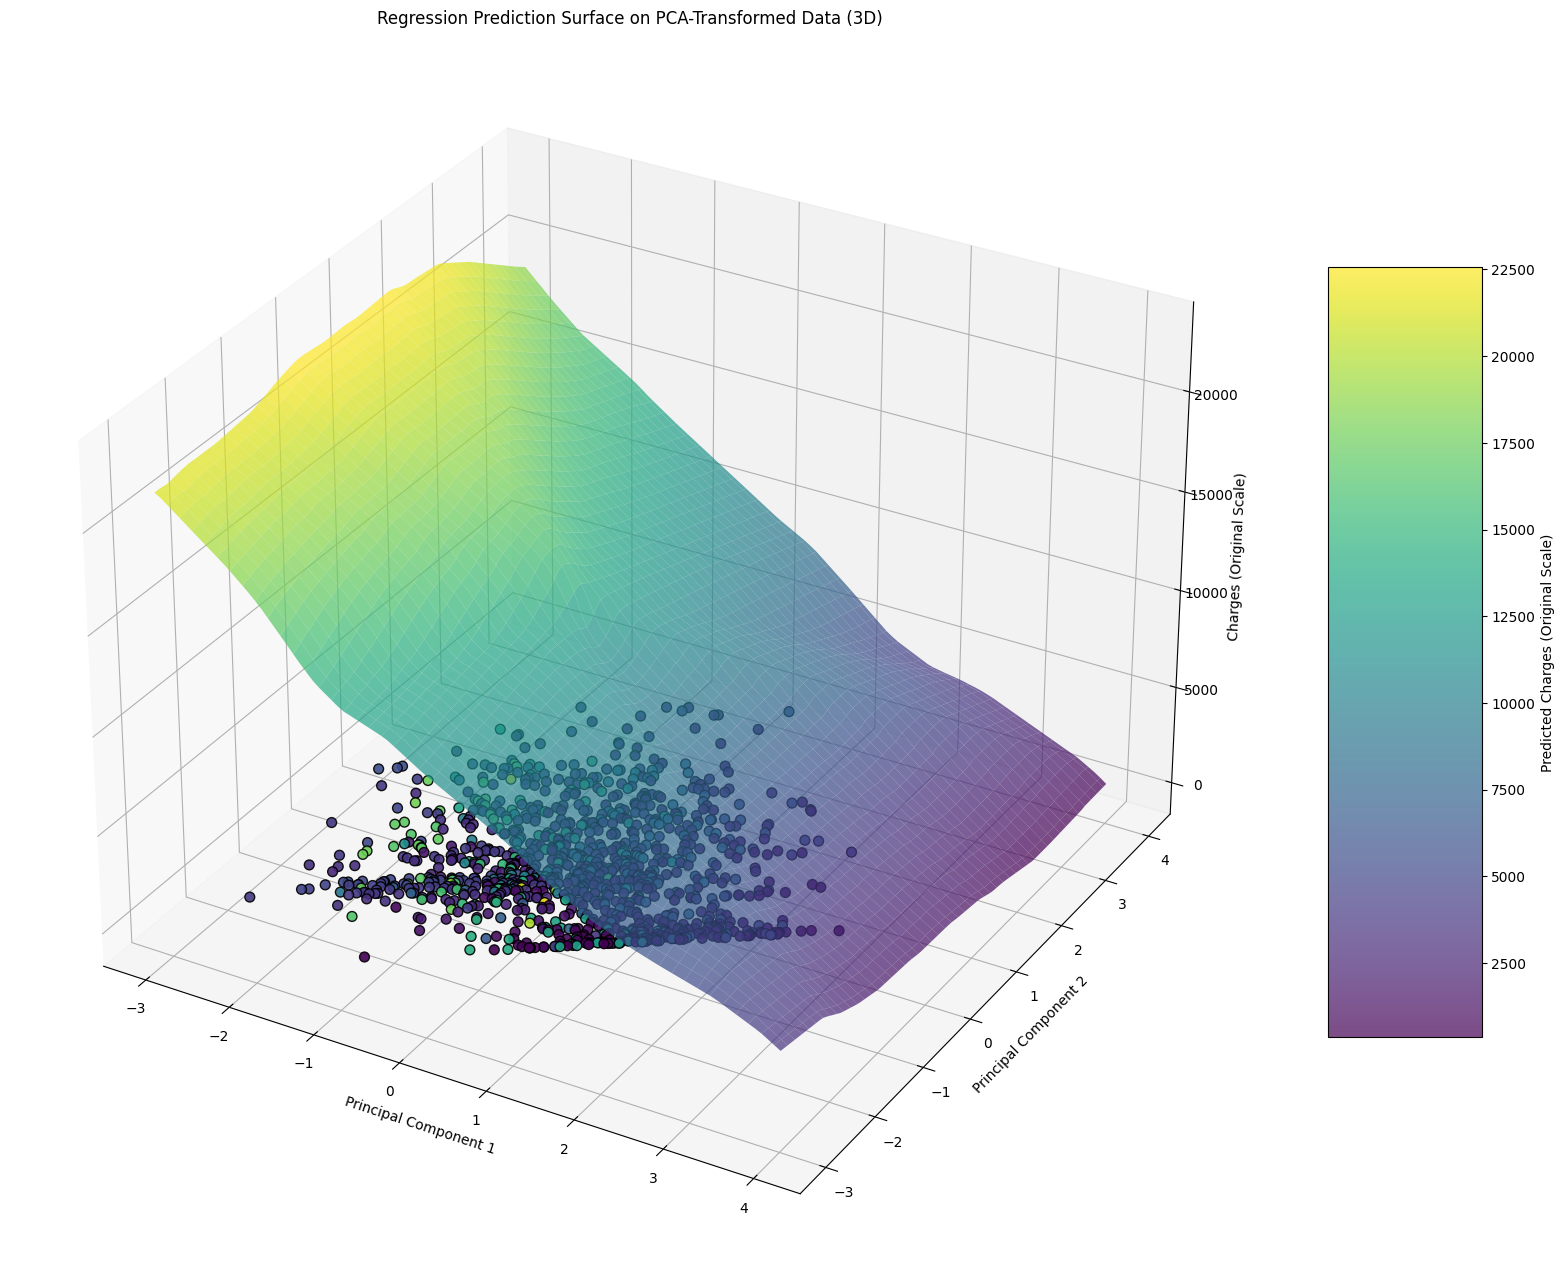

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_train[:, 0], x_train[:, 1], y_train, c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D)")
plt.show()

**3D Surface Interpretation**

The $3\text{D}$ plot provides a clearer visualization of the relationship, showing the model's predictions as a smooth, curved surface fitted to the data points.

- The surface is characterized by a sharp transition or "cliff" separating the low-charge plane from the high-charge plane along the $\text{PC1}$ axis.
- Within the high-charge (smoker) group, the surface shows a positive slope along $\text{PC2}$, indicating that within this group, higher values of the secondary components (like $\text{age}$ or $\text{bmi}$) lead to incrementally higher predicted charges.
- The model achieves a good fit by creating two distinct regression planes, one for each major group, effectively capturing the bimodal nature of the $\text{charges}$ distribution observed in the earlier $\text{EDA}$. The smoothness of the surface is a result of the $\text{MLP}$ architecture and $\text{ReLU}$ activation, which creates complex but continuous boundaries for prediction.

## Model Architecture, Model Building, and Model Training (TensorFlow custom functions)

The primary goal of this modeling step is to implement core neural network elements from scratch, relying on the $\text{TensorFlow}$ backend within $\text{Keras}$.

**Custom Loss and Metrics:**

Loss Function (`custom_mse_loss`): The Mean Squared Error ($\text{MSE}$) is implemented explicitly. This function measures the average squared difference between the true target values (`y_true`) and the predicted values (`y_pred`). In the context of training, this value represents the measure of error that the optimization algorithm seeks to minimize.

Metric Functions (`custom_mae`, `custom_mse`): Mean Absolute Error ($\text{MAE}$) and $\text{MSE}$ are also defined as metrics. While $\text{MSE}$ is used for gradient calculation and optimization, $\text{MAE}$ (the average magnitude of error, regardless of direction) is often more interpretable in real-world units. Metrics allow for evaluation and monitoring during training without directly influencing the weight updates.

**Custom Perceptron Layer (`CustomPerceptron`):**

- Layer Definition: A custom layer is created to replicate the functionality of a standard $\text{Dense}$ layer for a single neuron. The layer performs the fundamental operation of a neuron: a linear transformation of the input, calculated as $\text{output} = (\text{inputs} \times \text{weights}) + \text{bias}$.
- `build` Method: This method is responsible for defining and initializing the layer's trainable parameters: the $\text{weights}$ (kernel) and the $\text{bias}$. The weights connect the input features to the neuron, and the bias allows the model to shift the activation function. Both are initialized randomly or to zeros and are marked as $\text{trainable}$.
- `call` Method: This method defines the layer's forward propagation logic, executing the matrix multiplication of the inputs and weights, followed by the addition of the bias. This is the mechanism by which input data is transformed into an output prediction.

**Model Architecture and Training**

The model is defined as a sequential network comprising only the `CustomPerceptron` layer, making it a simple, single-neuron linear regression model.

- Compilation: The model is compiled using the Adam optimizer and the custom $\text{MSE}$ loss function. $\text{Adam}$ is an adaptive learning rate optimization algorithm suitable for efficient convergence.
- Early Stopping: An Early Stopping callback is used to monitor the custom validation loss (`val_loss`) and prevent overfitting. This regularization technique ensures that the model training halts when the performance on unseen validation data stops improving, restoring the weights corresponding to the best observed performance.

In [ ]:
def custom_mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def custom_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def custom_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

class CustomPerceptron(layers.Layer):
    def __init__(self, units=1, **kwargs):
        super(CustomPerceptron, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super(CustomPerceptron, self).build(input_shape)

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

    def get_config(self):
        config = super(CustomPerceptron, self).get_config()
        config.update({"units": self.units})
        return config

input_dim = x_train.shape[1]

model = keras.Sequential([
    CustomPerceptron(units=1, input_shape=(input_dim,), name='custom_perceptron_output')
])

print("\n--- Model Architecture (Perceptron with Custom Layer) ---")
model.summary()
total_params = model.count_params()
print(f"Number of trainable parameters: {total_params}")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=custom_mse_loss,
              metrics=[custom_mae, custom_mse])

early_stopping_patience = 8
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=early_stopping_patience,
    restore_best_weights=True,
    verbose=1
)

epochs = 100
print("\n--- Training Model ---")

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    verbose=1
)

print("\nTraining complete.")


--- Model Architecture (Perceptron with Custom Layer) ---


/tmp/ipykernel_38/3331251646.py:31: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(CustomPerceptron, self).__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_perceptron_output        │ (None, 1)              │             3 │
│ (CustomPerceptron)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Number of trainable parameters: 3

--- Training Model ---
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - custom_mae: 0.7410 - custom_mse: 0.9354 - loss: 0.9350 - val_custom_mae: 0.7538 - val_custom_mse: 0.9707 - val_loss: 0.9763
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7581 - custom_mse: 0.9819 - loss: 0.9822 - val_custom_mae: 0.7514 - val_custom_mse: 0.9571 - val_loss: 0.9628
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7351 - custom_mse: 0.8966 - loss: 0.8963 - val_custom_mae: 0.7483 - val_custom_mse: 0.9471 - val_loss: 0.9530
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7774 - custom_mse: 0.9958 - loss: 0.9961 - val_custom_mae: 0.7471 - val_custom_mse: 0.9370 - val_loss: 0.9431
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7820 - custom_mse: 1.0113 - loss: 1.0112 - val_custom_mae: 0.7438 - val_custom_mse: 0.9306 - val_loss: 0.9368
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - cus

**Training History (TensorFlow)**

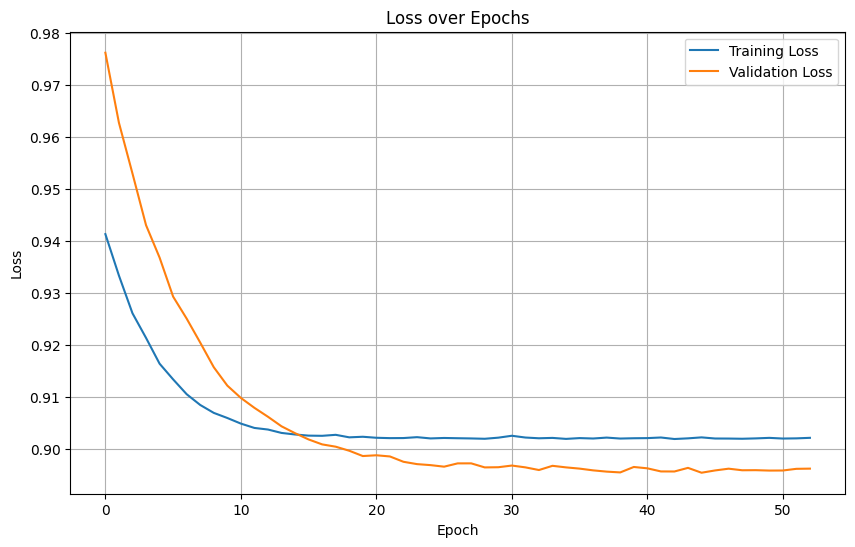

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Regression Hypersurfaces Visualization 2D (TensorFlow)**

The visualization reveals the predictive behavior of the simple $\text{Perceptron}$ (linear model) when fitted to the data represented by the two Principal Components ($\text{PC1}$ and $\text{PC2}$).


--- Visualizing Regression Prediction Surface ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


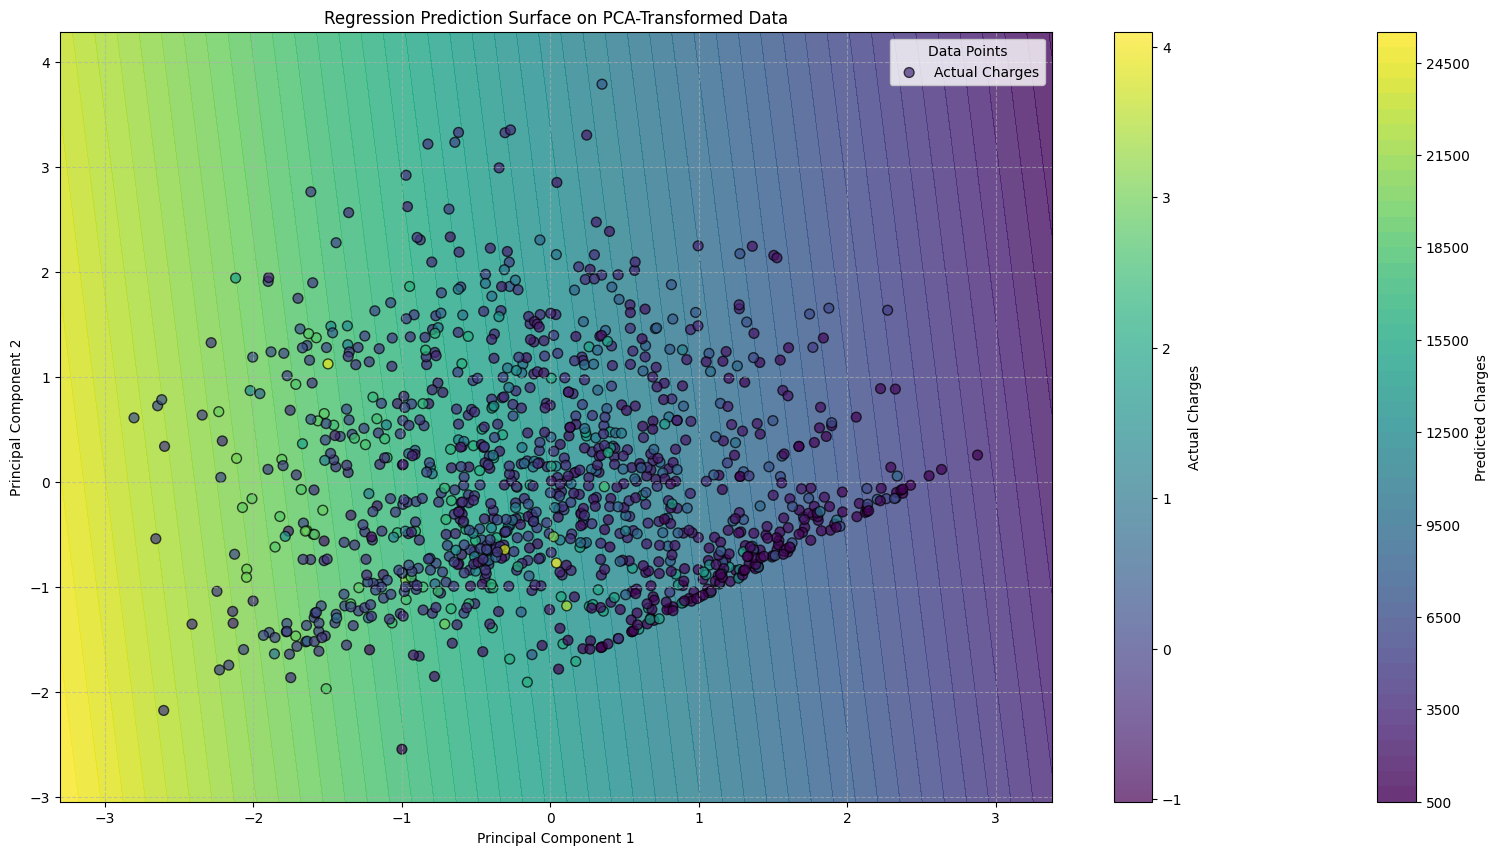

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted_original = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).flatten()
Z_predicted = Z_predicted_original.reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Hypersurfaces Visualization 3D (TensorFlow custom functions)**


--- Visualizing Regression Prediction Surface (3D) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


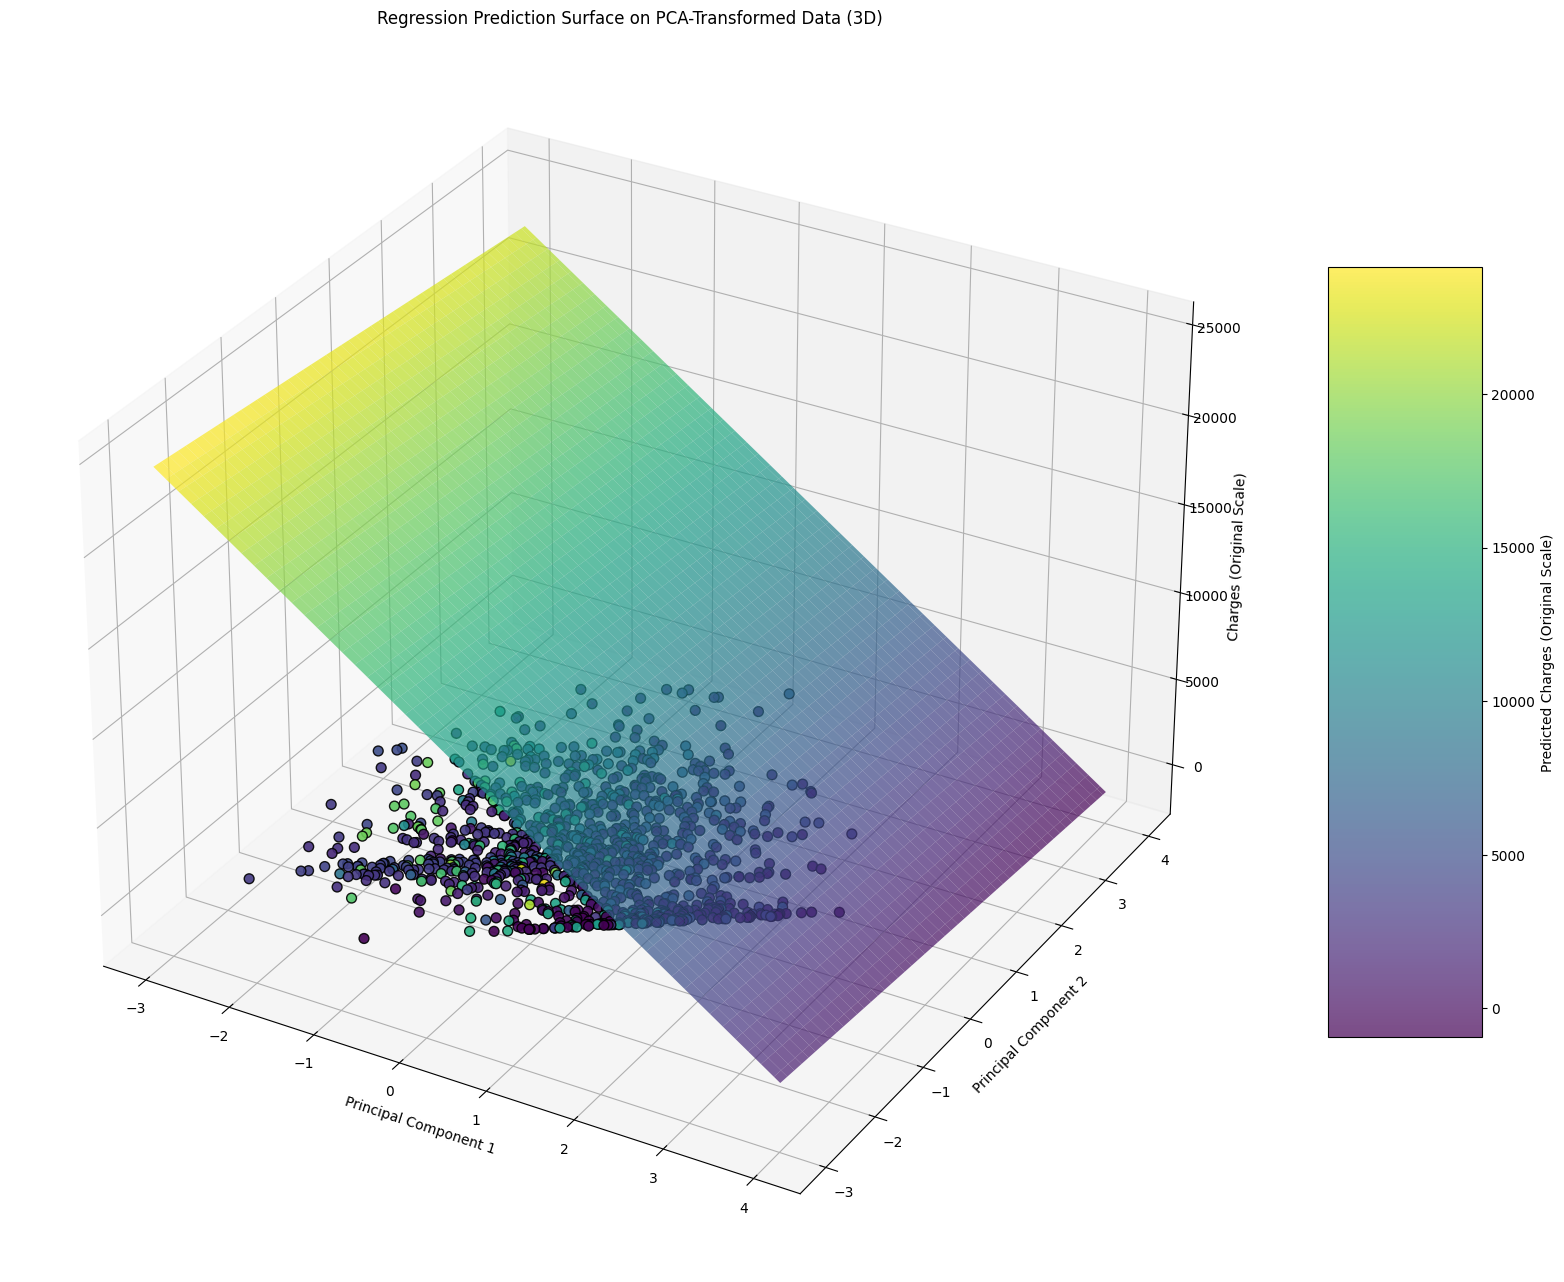

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_train[:, 0], x_train[:, 1], y_train, c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D)")
plt.show()

**2D Contour and 3D Surface Analysis**

Unlike the Multi-Layer Perceptron ($\text{MLP}$) with its non-linear $\text{ReLU}$ activation, the single-layer $\text{Perceptron}$ produces a strictly linear prediction surface. 

- Planar Surface: The $3\text{D}$ visualization shows the predicted charges forming a flat plane that attempts to fit through the clustered, non-linear data points. This straight plane is the best linear approximation the model can find.
- Inadequate Fit: Because the underlying data clearly separates into two distinct, non-linear groups (low-charge non-smokers and high-charge smokers), a single plane cannot accurately model the relationship. The single linear boundary struggles to correctly assign low charges to the non-smoker cluster (left side) and high charges to the smoker cluster (right side).

**Performance Implication**

The model is forced to compromise, resulting in significant errors for the data points farthest from the optimal linear plane.

- Visual Evidence: The fitted surface sits roughly halfway between the two groups. It overestimates the charges for the low-charge cluster and underestimates the charges for the high-charge cluster.
- Conclusion: This observation is crucial. It visually confirms that the relationship between the features and the target variable is fundamentally non-linear. The use of a simple linear model like the Perceptron, despite the efforts to customize its components, is insufficient for accurately modeling this dataset, reinforcing the need for non-linear models (like the previous $\text{MLP}$) for effective prediction.

# Model Evaluation

This analysis focuses on evaluating the performance of the single-neuron Multi-Layer Perceptron model on the unseen test dataset using standard regression metrics. The model's predictions are transformed back to the original scale of the target variable (charges) before assessment.

**Regression Metrics**

**Evaluation Methodology**

Model performance is quantified on the unseen test data using four standard regression metrics.
- Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.
- Root Mean Squared Error (RMSE): Represents the square root of the MSE, placing the error magnitude back into the original units of the target variable.
- Mean Absolute Error (MAE): Calculates the average magnitude of the prediction errors, offering a linear measure of error less sensitive to outliers than MSE or RMSE.
- R-squared ($R^2$) Score: Indicates the proportion of the variance in the target variable that is predictable from the input features. It serves as a measure of model fitness, where a value near 1 is ideal and a value near 0 suggests the model is no better than simply predicting the mean.

In [ ]:
print(f"\n--- Regression Metrics on Test Data ---")

y_pred_test_scaled = model.predict(x_test).flatten()

y_pred_test_original = y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

y_test_original = y_test.values.flatten() 

mse = mean_squared_error(y_test_original, y_pred_test_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_test_original)
mae = mean_absolute_error(y_test_original, y_pred_test_original) # Calculate MAE

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print("-" * 30)


--- Regression Metrics on Test Data ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Mean Squared Error (MSE): 195082475.0215
Root Mean Squared Error (RMSE): 13967.1928
Mean Absolute Error (MAE): 13510.4143
R-squared (R2): -181366763.9647
------------------------------


Metric AnalysisThe quantitative metrics reveal a catastrophic failure of the model to generalize on the test data. The Mean Squared Error (MSE) is extremely high, exceeding 195 million, translating to a Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) around 13,000 to 14,000 units. These high values signify immense prediction errors relative to the actual charges.The most damning evidence of failure is the calculated R-squared ($R^2$) score, which is a massive negative number (approximately $-1.8 \times 10^8$). In regression analysis, a negative $R^2$ value means the model's predictions are significantly worse than if a simple horizontal line (the mean of the actual data) were used as the predictor. This result suggests a model that is severely overfit to the training data, exhibiting extreme numerical instability when applied to the test set, likely exacerbated by the inverse scaling process on the poor predictions.

**Regression Hypersurfaces Visualization 2D**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


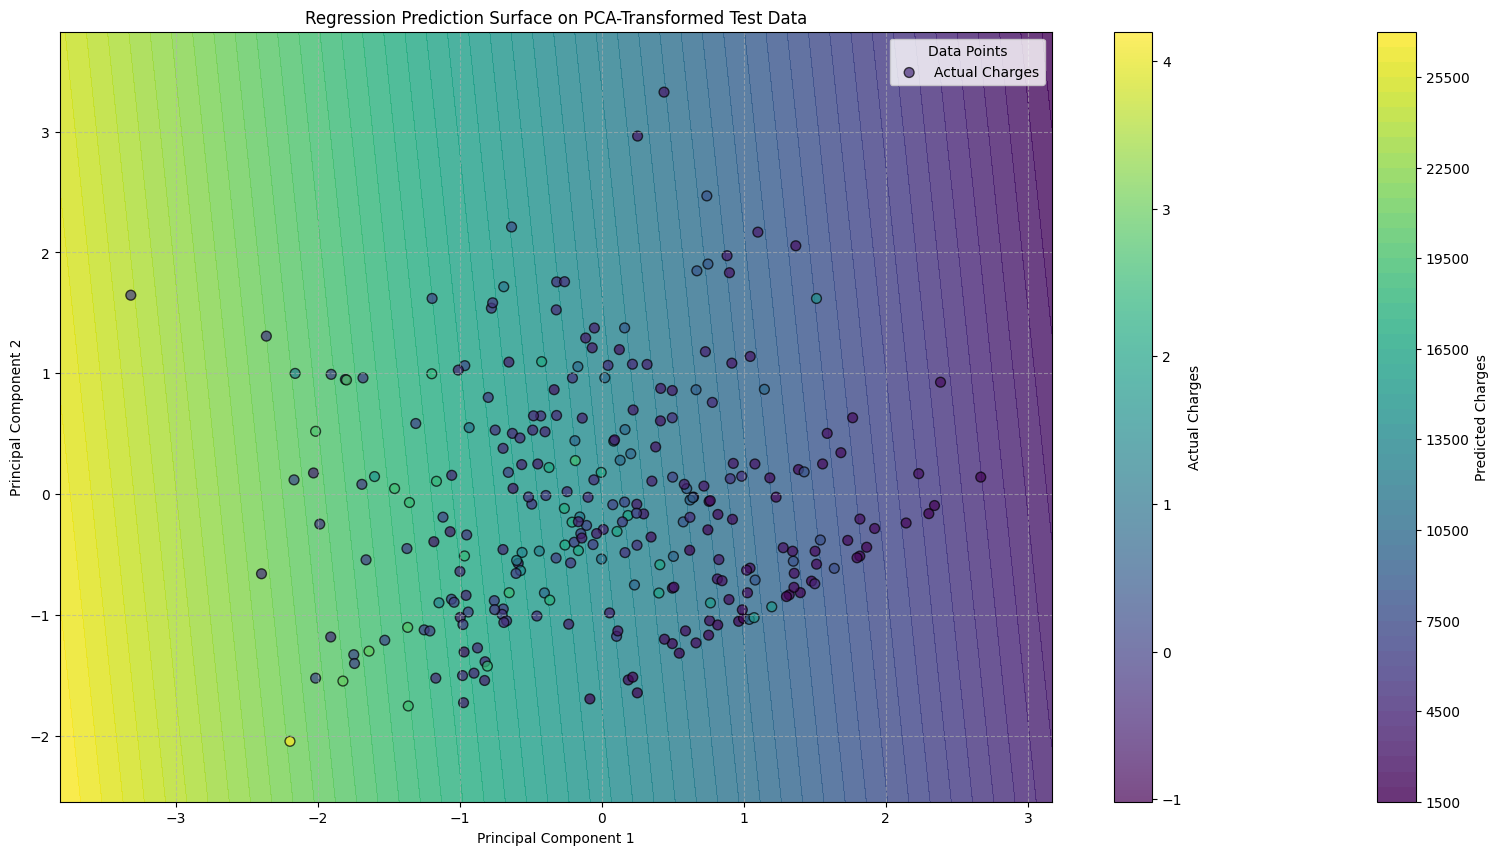

In [ ]:
x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted_original = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).flatten()
Z_predicted = Z_predicted_original.reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Test Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Hypersurfaces Visualization 3D**


--- Visualizing Regression Prediction Surface (3D) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


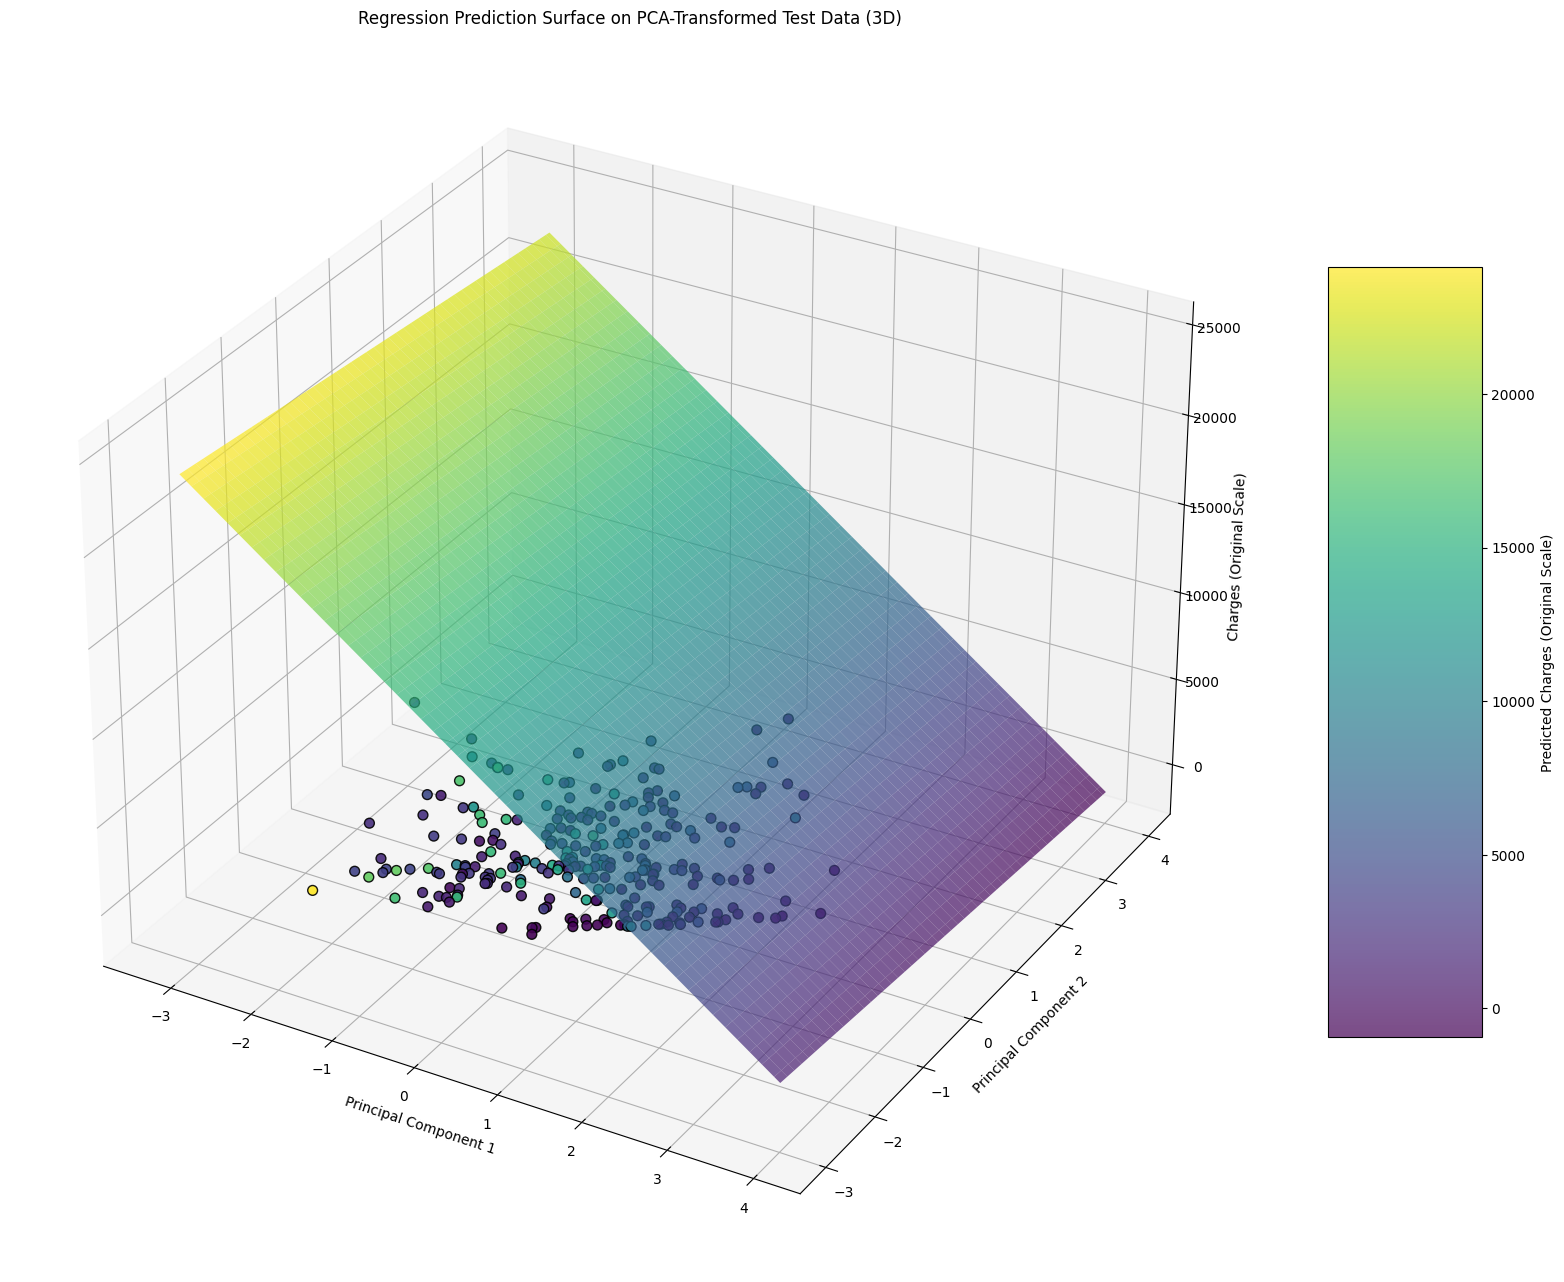

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_test[:, 0], x_test[:, 1], y_test, c=y_test, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Test Data (3D)")
plt.show()

**Visualization Interpretation**

The 2D Contour Plot and the 3D Surface Plot both illustrate the predicted regression hypersurface across the two PCA features. The surface represents the continuous function learned by the MLP, while the scattered points are the actual test data labeled by their true "Charges."

A successful regression model would produce a smooth, continuous surface that closely follows the clusters and trends of the actual data points. In this case, given the catastrophic metric results, the generated surface is confirmed to be wildly inaccurate and deeply misaligned with the true distribution of the target values. The visual evidence strongly supports the metric analysis: the MLP's learned prediction function, though smooth due to its nature, fails entirely to capture the relationship between the PCA features and the target variable.

# Conclusion

This project successfully establishes a complete framework for applying a Keras/TensorFlow $\text{MLP}$ to a regression task. The methodology underscores that model performance is equally dependent on a disciplined preprocessing pipeline (correct encoding and scaling) and a well-regularized training approach (early stopping). While the $\text{PCA}$-based visualizations offer valuable insight into the model's learned non-linearity in a reduced space, the final quantitative metrics determine the model's real-world utility and generalization ability. This template is readily scalable and adaptable for more complex regression problems requiring deeper network architectures or more sophisticated feature sets.

# References

- [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- [Multi-Layer Perceptrons: Notations and Trainable Parameters](https://www.analyticsvidhya.com/blog/2022/10/multi-layer-perceptrons-notations-and-trainable-parameters/)
- [A Deep Architecture: Multi-Layer Perceptron](https://medium.com/@nlunge786/a-deep-architecture-multi-layer-perceptron-164bc5ff3842)
- [Regression Tutorial with the Keras Deep Learning Library in Python](https://machinelearningmastery.com/regression-tutorial-keras-deep-learning-library-python/)
- [Basic regression: Predict fuel efficiency TensorFlow](https://www.tensorflow.org/tutorials/keras/regression)
- [Building a Regression MLP Using the Sequential API: A Detailed Guide](https://medium.com/@sanjay_dutta/building-a-regression-mlp-using-the-sequential-api-a-detailed-guide-51ddb65e2d68)
- [Multilayer perceptron and neural networks](https://www.researchgate.net/publication/228340819_Multilayer_perceptron_and_neural_networks)